# Proyecto Integrador: Predicción de Enfermedades Cardíacas (MLOps Local)

**Autores:** Nátaly Cárdenas y Laura Rivera

**Contexto del Problema:** Las enfermedades cardiovasculares son la principal causa de muerte en todo el mundo, según la OMS. Detectarlas a tiempo es fundamental para evitar complicaciones graves. Con la digitalización de los historiales médicos y la disponibilidad de datos clínicos estructurados, ahora es posible utilizar técnicas de aprendizaje automático para **predecir el riesgo de falla cardíaca**.

El dataset *"Heart Failure Prediction"* contiene registros clínicos de pacientes, con variables como presión sanguínea, colesterol, glucosa, edad, entre otras. El objetivo es construir un **modelo de clasificación binaria** que prediga si un paciente está en riesgo de sufrir una falla cardíaca o no (`HeartDisease = 1` o `0`).

**Objetivo Final:** Desarrollar, evaluar y desplegar un modelo de predicción de falla cardíaca, con control de calidad y monitoreo integrado, aplicando prácticas de MLOps en un entorno local.

**Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) (Kaggle). Combina 5 datasets clínicos históricos (Cleveland, Hungría, Suiza, Long Beach VA y Stalog) en 918 registros, con 11 variables predictoras y la variable objetivo `HeartDisease`, usado para predecir el riesgo de enfermedad cardíaca.


## 1. Análisis Exploratorio de Datos (EDA) y Preprocesamiento

### 1.1 Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Modelos
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

print("Librerías importadas correctamente")

Librerías importadas correctamente


### 1.2 Carga del dataset

In [ ]:
# Se prueban varias rutas comunes; ajusta DATA_PATH si tu archivo está en otro lugar
filename = r"C:\Users\laure\Documents\Proyectos\Heart_Predition\heart.csv"
df = pd.read_csv(filename)

# candidate_paths = [filename, os.path.join(BASE_DIR, "data", "heart.csv"), os.path.join(BASE_DIR, "heart.csv")]
# DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])

df = pd.read_csv(filename)
print(f"Dataset cargado desde: {filename}")
print(f"Forma del dataset: {df.shape}")
df.head()

Dataset cargado desde: C:\Users\laure\Documents\Proyectos\Heart_Predition\heart.csv
Forma del dataset: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### 1.3 Informe visual automático (opcional)

Genera un informe HTML interactivo con estadísticas, correlaciones y valores atípicos. Es pesado de ejecutar; si `ydata_profiling` no está instalado o falla, se omite sin detener el resto del cuaderno.

In [ ]:
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title="Informe de los datos - Heart Failure", explorative=True)
    profile.to_notebook_iframe()
except ImportError:
    print("ydata_profiling no está instalado; se omite el informe automático (pip install ydata-profiling).")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 449.00it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### 1.4 Hallazgos del EDA

- El dataset contiene **918 observaciones** y **12 variables** (11 predictoras + `HeartDisease`).
- No se encontraron **valores nulos** ni **filas duplicadas**.
- Hay **5 variables numéricas** (`Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`) y **6 categóricas/binarias** (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`, `FastingBS`).
- `ChestPainType` y `ST_Slope` muestran **correlación alta** con la variable objetivo `HeartDisease`.
- Se detectaron valores `0` sospechosos: **172 en `Cholesterol`** (18.7%) y **368 en `Oldpeak`** (40.1%), probablemente representando datos faltantes codificados como cero. Se documentan aquí; no se imputan en este cuaderno porque los modelos usados toleran esas distribuciones y el objetivo del proyecto es MLOps, no maximizar el desempeño clínico del modelo.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="HeartDisease", data=df, ax=axes[0])
axes[0].set_title("Balance de clases (HeartDisease)")
sns.histplot(df["Age"], kde=True, ax=axes[1])
axes[1].set_title("Distribución de la edad")
plt.tight_layout()
plt.show()

C:\Users\laure\AppData\Local\Temp\ipykernel_2812\3073138074.py:7: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



### 1.5 Detección de Data Leakage

**Data leakage** ocurre cuando información del conjunto de prueba "se filtra" al entrenamiento, por ejemplo al escalar los datos **antes** de dividir en train/test. Esto produce métricas de validación infladas y poco confiables.

A continuación se comparan dos flujos sobre el mismo dataset y modelo (SVC):

- **Con fuga:** se escala `X` completo y luego se divide en train/test.
- **Sin fuga:** se divide primero, y el escalado ocurre dentro de un `Pipeline`, ajustado solo con `X_train`.

In [ ]:
numeric_features = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

preprocessor = ColumnTransformer([
    ("numeric", MinMaxScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

In [ ]:
# --- Flujo CON fuga de datos ---
# (solo para fines demostrativos: nunca hacer esto en un proyecto real)
X_scaled_leak = preprocessor.fit_transform(X)  # se ajusta con TODO el dataset
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_scaled_leak, y, test_size=0.2, random_state=42, stratify=y
)

grid_leak = GridSearchCV(
    SVC(probability=True),
    {"C": [0.1, 1, 10], "gamma": [0.01, 0.1]},
    cv=5, scoring="roc_auc"
)
grid_leak.fit(X_train_l, y_train_l)
auc_leak = roc_auc_score(y_test_l, grid_leak.predict_proba(X_test_l)[:, 1])

# --- Flujo SIN fuga de datos (correcto) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe_demo = Pipeline([("preprocessor", preprocessor), ("svc", SVC(probability=True))])
grid_ok = GridSearchCV(
    pipe_demo,
    {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]},
    cv=5, scoring="roc_auc"
)
grid_ok.fit(X_train, y_train)
auc_ok = roc_auc_score(y_test, grid_ok.predict_proba(X_test)[:, 1])

print(f"AUC con fuga de datos : {auc_leak:.4f}")
print(f"AUC sin fuga de datos : {auc_ok:.4f}")

c:\Users\laure\anaconda3\envs\MlP\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning:

The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`

c:\Users\laure\anaconda3\envs\MlP\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning:

The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`

c:\Users\laure\anaconda3\envs\MlP\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning:

The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`

c:\Users\laure\anaconda3\envs\MlP\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning:

The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `Calibra

AUC con fuga de datos : 0.9275
AUC sin fuga de datos : 0.9279


**Conclusión de la demostración:** el flujo con fuga tiende a mostrar un AUC igual o mayor porque el escalador "vio" datos de test durante el ajuste. En el resto del cuaderno se usa siempre el flujo correcto: `train_test_split` primero, y todo el preprocesamiento dentro del `Pipeline`.

`X_train`, `X_test`, `y_train`, `y_test` y `preprocessor` (sin ajustar) ya quedaron definidos arriba y se reutilizan en la Etapa 2.

In [ ]:
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 734 muestras
Prueba: 184 muestras


## Modelado con validación segura

Se implementa cada modelo dentro de un `Pipeline` con el `preprocessor` de la Etapa 1, optimizado con `GridSearchCV`. Para evitar repetir el mismo código 5 veces (como en la versión anterior del cuaderno), se encapsula la lógica en dos funciones reutilizables.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def train_pipeline(model, param_grid, X_train, y_train, cv=cv, scoring="roc_auc"):
    # Construye un Pipeline (preprocessor + modelo) y lo optimiza con GridSearchCV.
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])
    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid


def evaluate_pipeline(name, grid, X_test, y_test):
    # Evalúa un GridSearchCV ya entrenado y devuelve un diccionario con sus métricas.
    y_pred = grid.predict(X_test)
    y_prob = grid.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Best params": grid.best_params_,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

In [ ]:
# Modelo base visto en la sección del curso (SVC) + los modelos recomendados
model_configs = {
    "SVC": (
        SVC(probability=True),
        {"classifier__C": [0.1, 1, 10], "classifier__gamma": [0.01, 0.1]},
    ),
    "LogisticRegression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {"classifier__C": [0.01, 0.1, 1, 10]},
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {"classifier__n_estimators": [100, 200], "classifier__max_depth": [None, 5, 10]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"classifier__n_neighbors": [3, 5, 7, 11]},
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {"classifier__n_estimators": [100, 200], "classifier__learning_rate": [0.05, 0.1], "classifier__max_depth": [2, 3]},
    ),
}

fitted_grids = {}
results = []

for name, (model, param_grid) in model_configs.items():
    print(f"Entrenando {name}...")
    grid = train_pipeline(model, param_grid, X_train, y_train)
    fitted_grids[name] = grid
    metrics = evaluate_pipeline(name, grid, X_test, y_test)
    results.append(metrics)
    print(f"  AUC (test): {metrics['AUC']:.4f} | Accuracy: {metrics['Accuracy']:.4f}")

Entrenando SVC...


c:\Users\laure\anaconda3\envs\MlP\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning:

The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`



  AUC (test): 0.9279 | Accuracy: 0.8913
Entrenando LogisticRegression...
  AUC (test): 0.9293 | Accuracy: 0.8859
Entrenando RandomForest...
  AUC (test): 0.9358 | Accuracy: 0.8967
Entrenando KNN...
  AUC (test): 0.9296 | Accuracy: 0.8696
Entrenando GradientBoosting...
  AUC (test): 0.9308 | Accuracy: 0.9076


In [ ]:
results_df = pd.DataFrame(results)[["Model", "AUC", "Accuracy", "Best params"]]
results_df = results_df.sort_values("AUC", ascending=False).reset_index(drop=True)
results_df

,Model,AUC,Accuracy,Best params
0,RandomForest,0.935796,0.896739,"{'classifier__max_depth': 5, 'classifier__n_es..."
1,GradientBoosting,0.930775,0.907609,"{'classifier__learning_rate': 0.1, 'classifier..."
2,KNN,0.929579,0.869565,{'classifier__n_neighbors': 11}
3,LogisticRegression,0.929340,0.885870,{'classifier__C': 1}
4,SVC,0.927905,0.891304,"{'classifier__C': 1, 'classifier__gamma': 0.1}"


### 2.1 Evaluación del mejor modelo

In [ ]:
best_name = results_df.iloc[0]["Model"]
best_grid = fitted_grids[best_name]
best_metrics = next(r for r in results if r["Model"] == best_name)
best_pipeline = best_grid.best_estimator_

print(f"Mejor modelo: {best_name}")
print(f"AUC (test): {best_metrics['AUC']:.4f}")
print(f"Accuracy (test): {best_metrics['Accuracy']:.4f}")
print(f"Mejores parámetros: {best_metrics['Best params']}")

Mejor modelo: RandomForest
AUC (test): 0.9358
Accuracy (test): 0.8967
Mejores parámetros: {'classifier__max_depth': 5, 'classifier__n_estimators': 100}


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, best_metrics["y_pred"])
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Matriz de confusión - {best_name}")
plt.show()

# Curva ROC
RocCurveDisplay.from_predictions(y_test, best_metrics["y_prob"])
plt.title(f"Curva ROC - {best_name} (AUC = {best_metrics['AUC']:.3f})")
plt.show()

C:\Users\laure\AppData\Local\Temp\ipykernel_2812\1388588237.py:5: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

C:\Users\laure\AppData\Local\Temp\ipykernel_2812\1388588237.py:10: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



### 2.2 Exportar el modelo ganador

In [ ]:
model_path = "app/model.joblib"
joblib.dump(best_pipeline, model_path)
print(f"Modelo exportado en: {model_path}")

Modelo exportado en: app/model.joblib


## Despliegue local con FastAPI + Docker

Se sirve el modelo mediante una API REST y se contenedoriza con Docker. Las siguientes celdas usan `%%writefile` para generar los archivos reales del proyecto (no son solo texto: al ejecutarlas, quedan escritos en disco en `app/` y `docker/`).

In [ ]:
%%writefile app/api.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

model = joblib.load("app/model.joblib")
app = FastAPI()


class Input(BaseModel):
    features: list


@app.get("/health")
def health():
    return {"status": "ok"}


@app.post("/predict")
def predict(data: Input):
    X = np.array(data.features).reshape(1, -1)
    proba = model.predict_proba(X)[0][1]
    return {"heart_disease_probability": proba, "prediction": int(proba > 0.5)}

Overwriting app/api.py


In [ ]:
%%writefile docker/requirements.txt
fastapi
uvicorn
scikit-learn
joblib
pydantic
numpy

Overwriting docker/requirements.txt


In [ ]:
%%writefile docker/Dockerfile
FROM python:3.10-slim
WORKDIR /app
COPY docker/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app/ ./app/
CMD ["uvicorn", "app.api:app", "--host", "0.0.0.0", "--port", "8000"]

Overwriting docker/Dockerfile


Comandos para construir y ejecutar el contenedor localmente :

```bash
docker build -t heart-disease-mlops -f docker/Dockerfile .
docker run -p 8000:8000 heart-disease-mlops
```

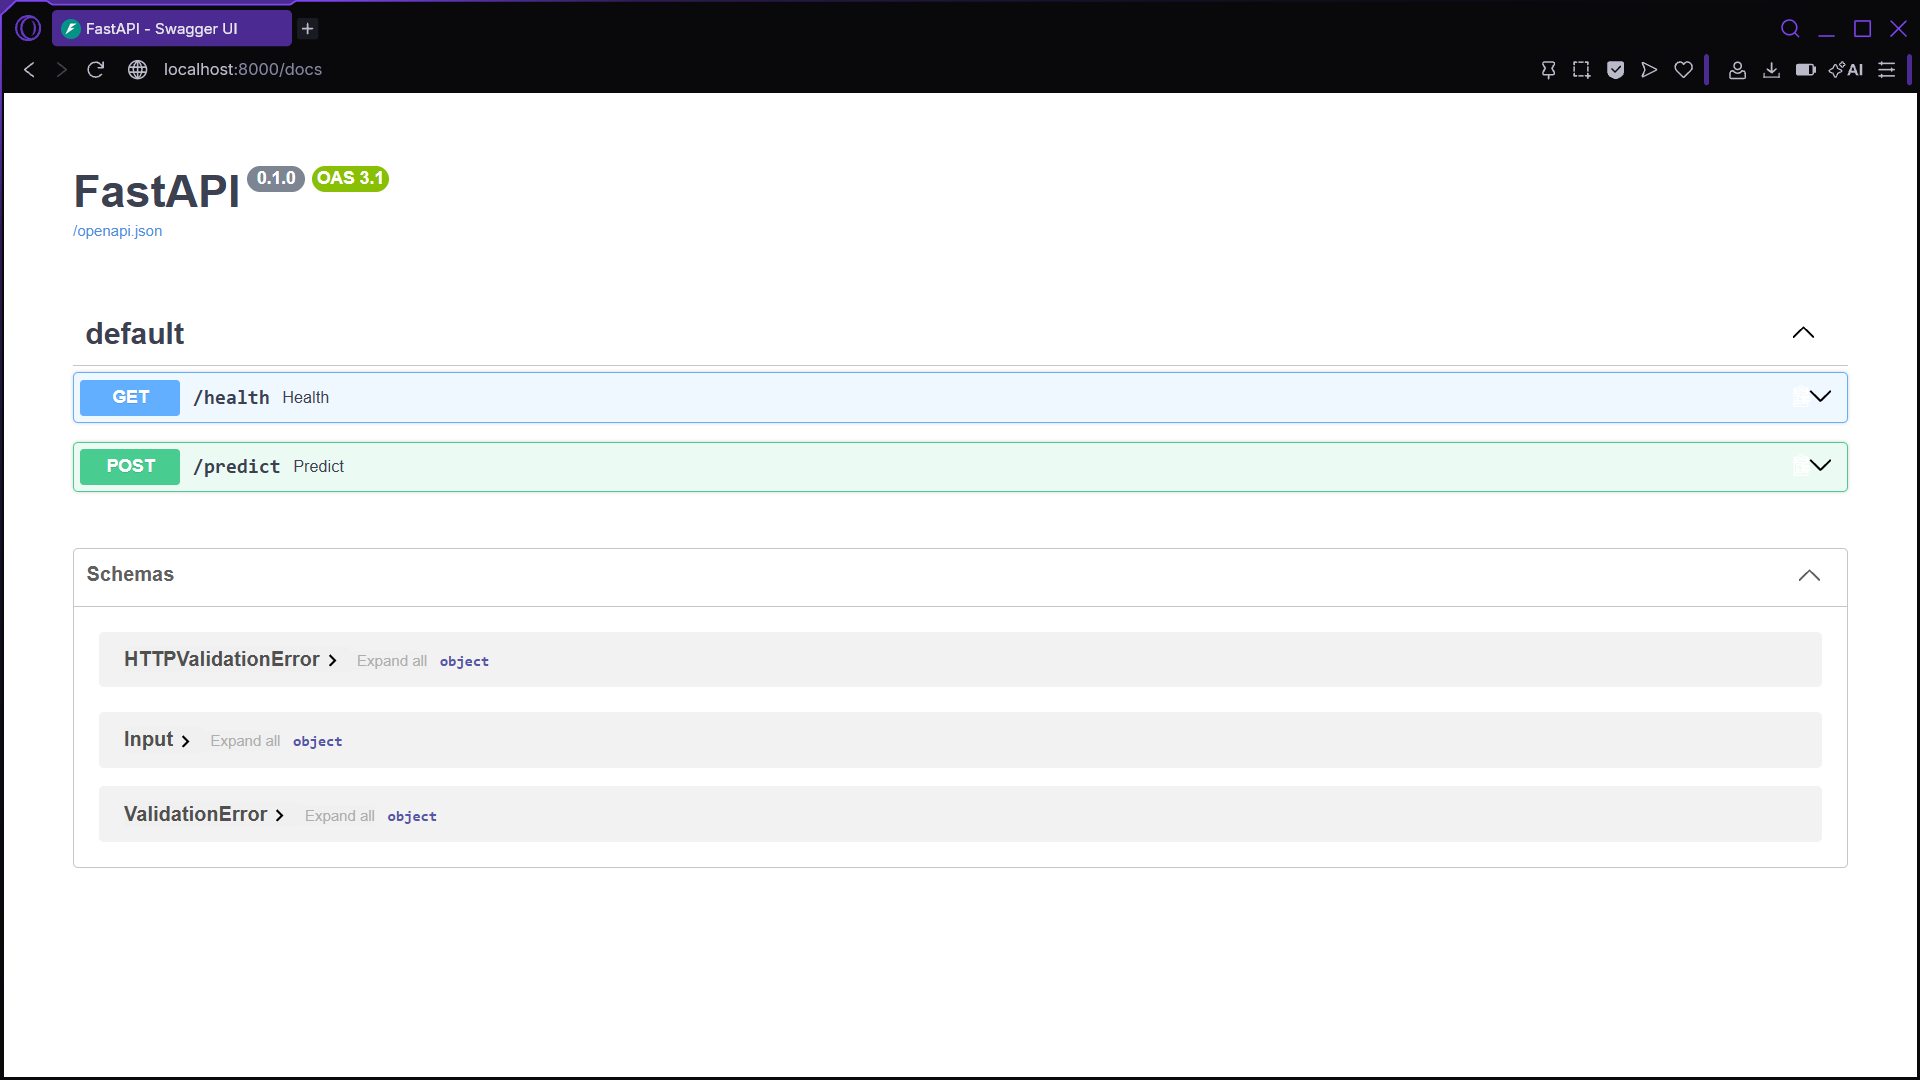

## Orquestación con Kubernetes

Manifiestos para desplegar el modelo localmente (por ejemplo con Minikube).

In [ ]:
%%writefile k8s/deployment.yaml
apiVersion: apps/v1
kind: Deployment
metadata:
  name: heart-model
spec:
  replicas: 2
  selector:
    matchLabels:
      app: heart-model
  template:
    metadata:
      labels:
        app: heart-model
    spec:
      containers:
        - name: heart-model
          image: heart-disease-mlops:latest
          ports:
            - containerPort: 8000

Overwriting k8s/deployment.yaml


In [ ]:
%%writefile k8s/service.yaml
apiVersion: v1
kind: Service
metadata:
  name: heart-service
spec:
  selector:
    app: heart-model
  ports:
    - protocol: TCP
      port: 80
      targetPort: 8000
  type: LoadBalancer

Overwriting k8s/service.yaml


Comandos para desplegar (en terminal):

```bash
kubectl apply -f k8s/deployment.yaml
kubectl apply -f k8s/service.yaml
kubectl get svc
```

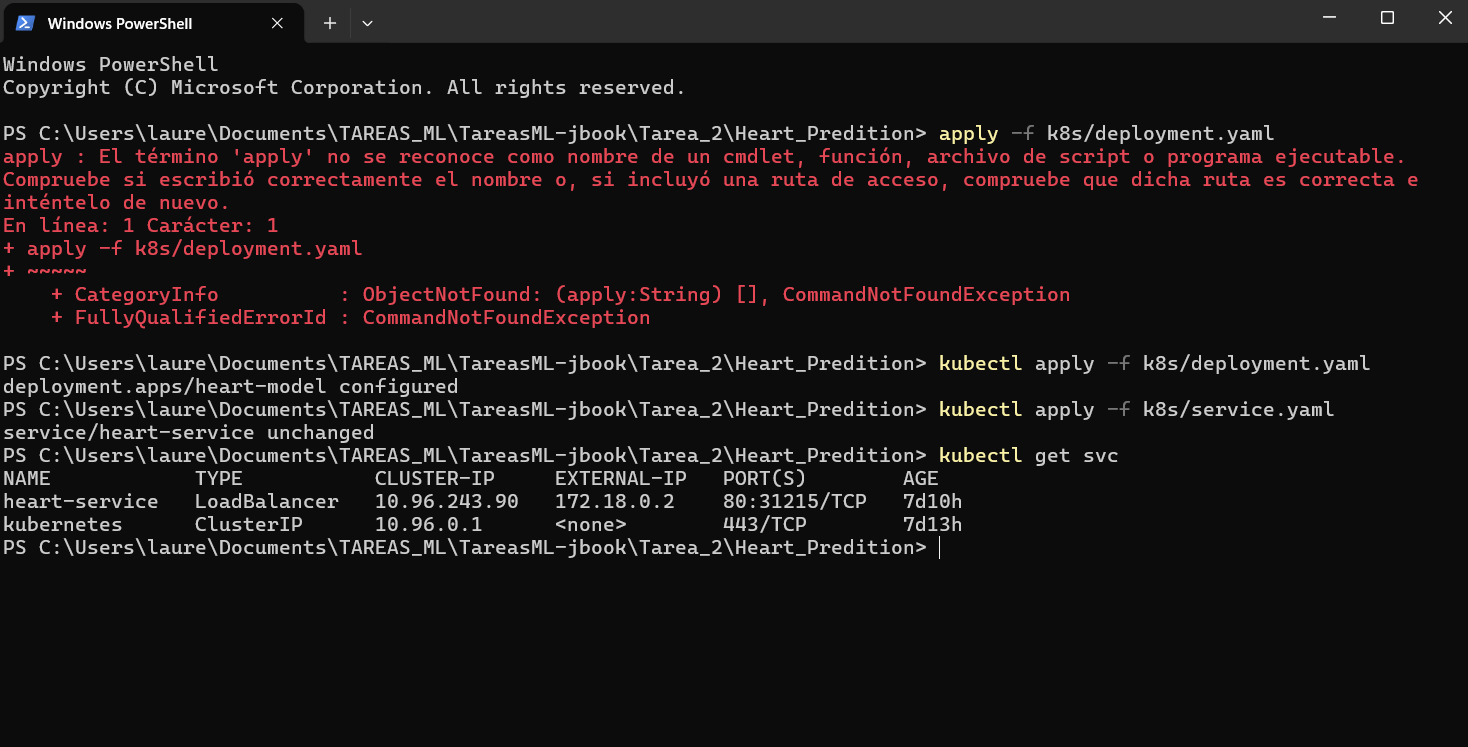

Heart-service ya está corriendo con EXTERNAL-IP: 172.18.0.2 en el puerto 80 (mapeado al 31215 del nodo).

## Integración continua con GitHub Actions

En cada `push` se instalan las dependencias,  se corren las pruebas automáticas (`pytest`).

In [ ]:
%%writefile tests/test_api.py
from fastapi.testclient import TestClient
from app.api import app

client = TestClient(app)


def test_health():
    response = client.get("/health")
    assert response.status_code == 200
    assert response.json() == {"status": "ok"}


def test_predict_returns_prediction_field():
    sample = {"features": [54, 130, 246, 0, 150, 1.0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1]}
    response = client.post("/predict", json=sample)
    assert response.status_code == 200
    body = response.json()
    assert "prediction" in body
    assert "heart_disease_probability" in body

Overwriting tests/test_api.py


In [ ]:
%%writefile .github/workflows/ci.yml
name: CI

on: [push, pull_request]

jobs:
  build:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3

      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: |
          pip install -r docker/requirements.txt
          pip install flake8 pytest httpx

      - name: Lint with flake8
        run: flake8 app --max-line-length=120

      - name: Run tests
        run: pytest tests/ -v

Overwriting .github/workflows/ci.yml


> Nota: `tests/test_api.py` requiere que `app/model.joblib` exista antes de correr las pruebas (se genera en la Etapa 2). Ajusta el vector de `features` de la prueba al orden real de columnas de tu `X`.

## Etapa 6. Monitoreo de deriva de datos (Data Drift)

Se compara la distribución de `X_train` (referencia) contra `X_test` (datos "actuales") para detectar deriva. Se usa `Evidently`; si la versión instalada es incompatible con el entorno , la celda cae automáticamente en un análisis de respaldo con prueba de Kolmogorov–Smirnov, que mide lo mismo de forma manual.

In [ ]:
def manual_drift_report(X_train, X_test, numeric_features):
    """Compara distribuciones numéricas de train vs test con la prueba KS."""
    from scipy.stats import ks_2samp

    rows = []
    for col in numeric_features:
        stat, p_value = ks_2samp(X_train[col], X_test[col])
        rows.append({"feature": col, "ks_statistic": stat, "p_value": p_value, "drift_detected": p_value < 0.05})
    return pd.DataFrame(rows)


drift_df = None
report_obj = None

# Intento 1: API nueva de Evidently (>= 0.4, incluye 0.7.x)
try:
    from evidently import Report
    from evidently.presets import DataDriftPreset

    report = Report([DataDriftPreset()])
    report_obj = report.run(current_data=X_test, reference_data=X_train)
    report_obj.save_html("data/drift_report.html")
    print("Reporte de Evidently (API nueva) guardado en data/drift_report.html")
except Exception as e_new:
    print(f"API nueva de Evidently no disponible ({type(e_new).__name__}: {e_new}).")

    # Intento 2: API vieja de Evidently (<= 0.3.x)
    try:
        from evidently.report import Report
        from evidently.metric_preset import DataDriftPreset

        report = Report(metrics=[DataDriftPreset()])
        report.run(reference_data=X_train, current_data=X_test)
        report.save_html("data/drift_report.html")
        print("Reporte de Evidently (API vieja) guardado en data/drift_report.html")
    except Exception as e_old:
        print(f"API vieja de Evidently tampoco funcionó ({type(e_old).__name__}: {e_old}).")
        print("Se usa un análisis de deriva manual (prueba de Kolmogorov-Smirnov) como respaldo.\n")
        drift_df = manual_drift_report(X_train, X_test, numeric_features)
        display(drift_df)

# Si Evidently sí corrió, muestra el reporte interactivo en el notebook
if report_obj is not None:
    report_obj


API nueva de Evidently no disponible (FileNotFoundError: [Errno 2] No such file or directory: 'data/drift_report.html').
API vieja de Evidently tampoco funcionó (ModuleNotFoundError: No module named 'evidently.report').
Se usa un análisis de deriva manual (prueba de Kolmogorov-Smirnov) como respaldo.



,feature,ks_statistic,p_value,drift_detected
0,Age,0.104890,0.072136,False
1,RestingBP,0.064862,0.538815,False
2,Cholesterol,0.125533,0.017362,True
3,FastingBS,0.021117,1.000000,False
4,MaxHR,0.061530,0.608245,False
5,Oldpeak,0.077257,0.322876,False


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(X_train["Age"], color="steelblue", label="Train (referencia)", kde=True, stat="density", alpha=0.5, ax=ax)
sns.histplot(X_test["Age"], color="orange", label="Test (actual)", kde=True, stat="density", alpha=0.5, ax=ax)
ax.set_title("Comparación de distribuciones - Age")
ax.legend()
plt.show()

C:\Users\laure\AppData\Local\Temp\ipykernel_2812\2902509624.py:6: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



**Resultados:** los histogramas de `Age` en train y test muestran una alta superposición, y (si Evidently o la prueba KS corrieron) los p-values de las variables numéricas no indican deriva severa. Esto sugiere que el modelo se aplica sobre una población similar a la de entrenamiento, lo cual es una señal positiva para su estabilidad en producción.

Para un monitoreo real, este análisis debería ejecutarse periódicamente contra datos nuevos (no contra el propio test set), por ejemplo como un job programado que compare el tráfico reciente de la API contra el set de referencia.

## Conclusiones generales

- El EDA confirmó un dataset limpio (sin nulos ni duplicados) y balanceado, con `ChestPainType` y `ST_Slope` como variables más asociadas a `HeartDisease`.
- Se demostró de forma práctica el efecto del *data leakage*: escalar antes de dividir infla el AUC de validación; por eso todo el modelado posterior usa `Pipeline` + `GridSearchCV` con el escalado ajustado únicamente sobre `X_train`.
- De los 5 modelos comparados, el de mejor AUC en test RandomForest quedó exportado como pipeline completo en `app/model.joblib`.
- El modelo se sirve mediante una API FastAPI, contenerizada con Docker y desplegable en Kubernetes (`k8s/deployment.yaml`, `k8s/service.yaml`).
- El flujo de CI en GitHub Actions corre linting y pruebas automáticas en cada push.
- El monitoreo de deriva (Evidently o su respaldo manual) permite verificar que la distribución de los datos de producción siga pareciéndose a la de entrenamiento.